In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
protein_name = "trp_cage"

In [3]:
import os
import torch
import mdtraj as md
import numpy as np
from tqdm import tqdm
from pathlib import Path
from datasets.dataset_utils_empty import Molecules, DEShawDataset, AtomSelection, to_angstrom, norm_stds
from models.graph_transformer import GraphTransformer
from evaluate.evaluators import TicEvaluator
from evaluate.evaluate_fastfolders import CLUSTER_ENDPOINTS
from evaluate.msm_utils import discretize_trajectory
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

KB = 0.83144626181  # This is the Boltzmann constant conversed from J/K (Kg, m^2 / s^2 / K) to -> g/mol, angstroms, ps and K.
temp_data = 300  # Temperature in K
masses = 12.0  # Mass of carbon in g/mol
friction = 1.0  # Friction coefficient in ps^-1

os.environ["CUDA_VISIBLE_DEVICES"] = "9"

def linear_warmup_cosine_decay_lr_scheduler(optimizer, warmup_steps, total_steps, lr_min=0.0, lr_max=1.0):
    """
    Linear warmup with cosine decay 
    """
    def lr_lambda(current_step: int):
        if current_step < warmup_steps:
            # Linear warmup
            warmup_factor = current_step / float(max(1, warmup_steps))
            return lr_min + warmup_factor * (lr_max - lr_min)
        else:
            # Cosine decay
            progress = (current_step - warmup_steps) / float(max(1, total_steps - warmup_steps))
            return lr_min + 0.5 * (lr_max - lr_min) * (1 + torch.cos(torch.tensor(torch.pi * progress)))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

def plot_losses(
    train_losses: np.ndarray, test_losses: np.ndarray, title: str, true_rate=None
) -> None:
    plt.figure()
    n_epochs = len(test_losses) - 1
    x_train = np.linspace(0, n_epochs, len(train_losses))
    x_test = np.arange(n_epochs + 1)

    plt.plot(x_train, train_losses, label="Train Loss")
    plt.plot(x_test, test_losses, label="Test Loss")
    if true_rate is not None:
        plt.axhline(true_rate, color="r", linestyle="--", label="True Rate (Counting MD Simulations)")
    plt.legend()
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.yscale("log")

/home/sanjeevr/miniforge3/envs/alphaflow/lib/python3.9/site-packages/mdtraj/__init__.py:55: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 1.21.2)
  from ._lprmsd import lprmsd


In [4]:
device = torch.device(torch.device("cuda:9"))

# Load the MD data

gen_mode = "om_interpolate" # Mode of generation, "iid" or "langevin"
subsample = None # Give integer if only a random subset of the samples should be analyzed (if None, all samples are used)
append_exp_name = "test_md" # Append string to the experiment name"
append_exp_name_str = '_' + append_exp_name if append_exp_name else ''
eval_folder = f"./saved_models/{protein_name}/main_eval_output_{gen_mode}{append_exp_name_str}"

pdb_file = f"./datasets/folded_pdbs/{Molecules[protein_name.upper()].value}-0-c-alpha.pdb"

md_samples_path = os.path.join(eval_folder, f"sample-{gen_mode}-md.pt")
om_points_path = os.path.join(eval_folder, f"sample-{gen_mode}.pt")
md_samples = torch.load(md_samples_path)
om_points = torch.load(om_points_path)

# Load cluster centers
cluster_centers_path = Path(
    os.path.join(
        "evaluate",
        "saved_references",
        f"saved_cluster_centers_{protein_name.upper()}.npy",
    )
)
tic_cluster_coords = np.load(cluster_centers_path)

iid_sample_path = Path(os.path.join(os.path.dirname(eval_folder), "main_eval_output_iid"))
# Get TICA
tic_evaluator = TicEvaluator(
    val_data=None,
    mol_name=protein_name,
    eval_folder=iid_sample_path,
    data_folder="datasets",
    folded_pdb_folder="datasets/folded_pdbs",
    bins=101,
    evalset="testset",
)
# assign TIC cluster centers to the reference samples
tic_cluster_assignments, transformed_samples = discretize_trajectory(
    md_samples, tic_evaluator, tic_cluster_coords
)

tic_cluster_assignments = torch.tensor(tic_cluster_assignments)


n_atoms = md_samples.shape[1]

transformed_samples.shape




/tmp/ipykernel_1442022/672978092.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  md_samples = torch.load(md_samples_path)
/tmp/ipykernel_1442022/672978092.py:16: Future

(160000, 2)

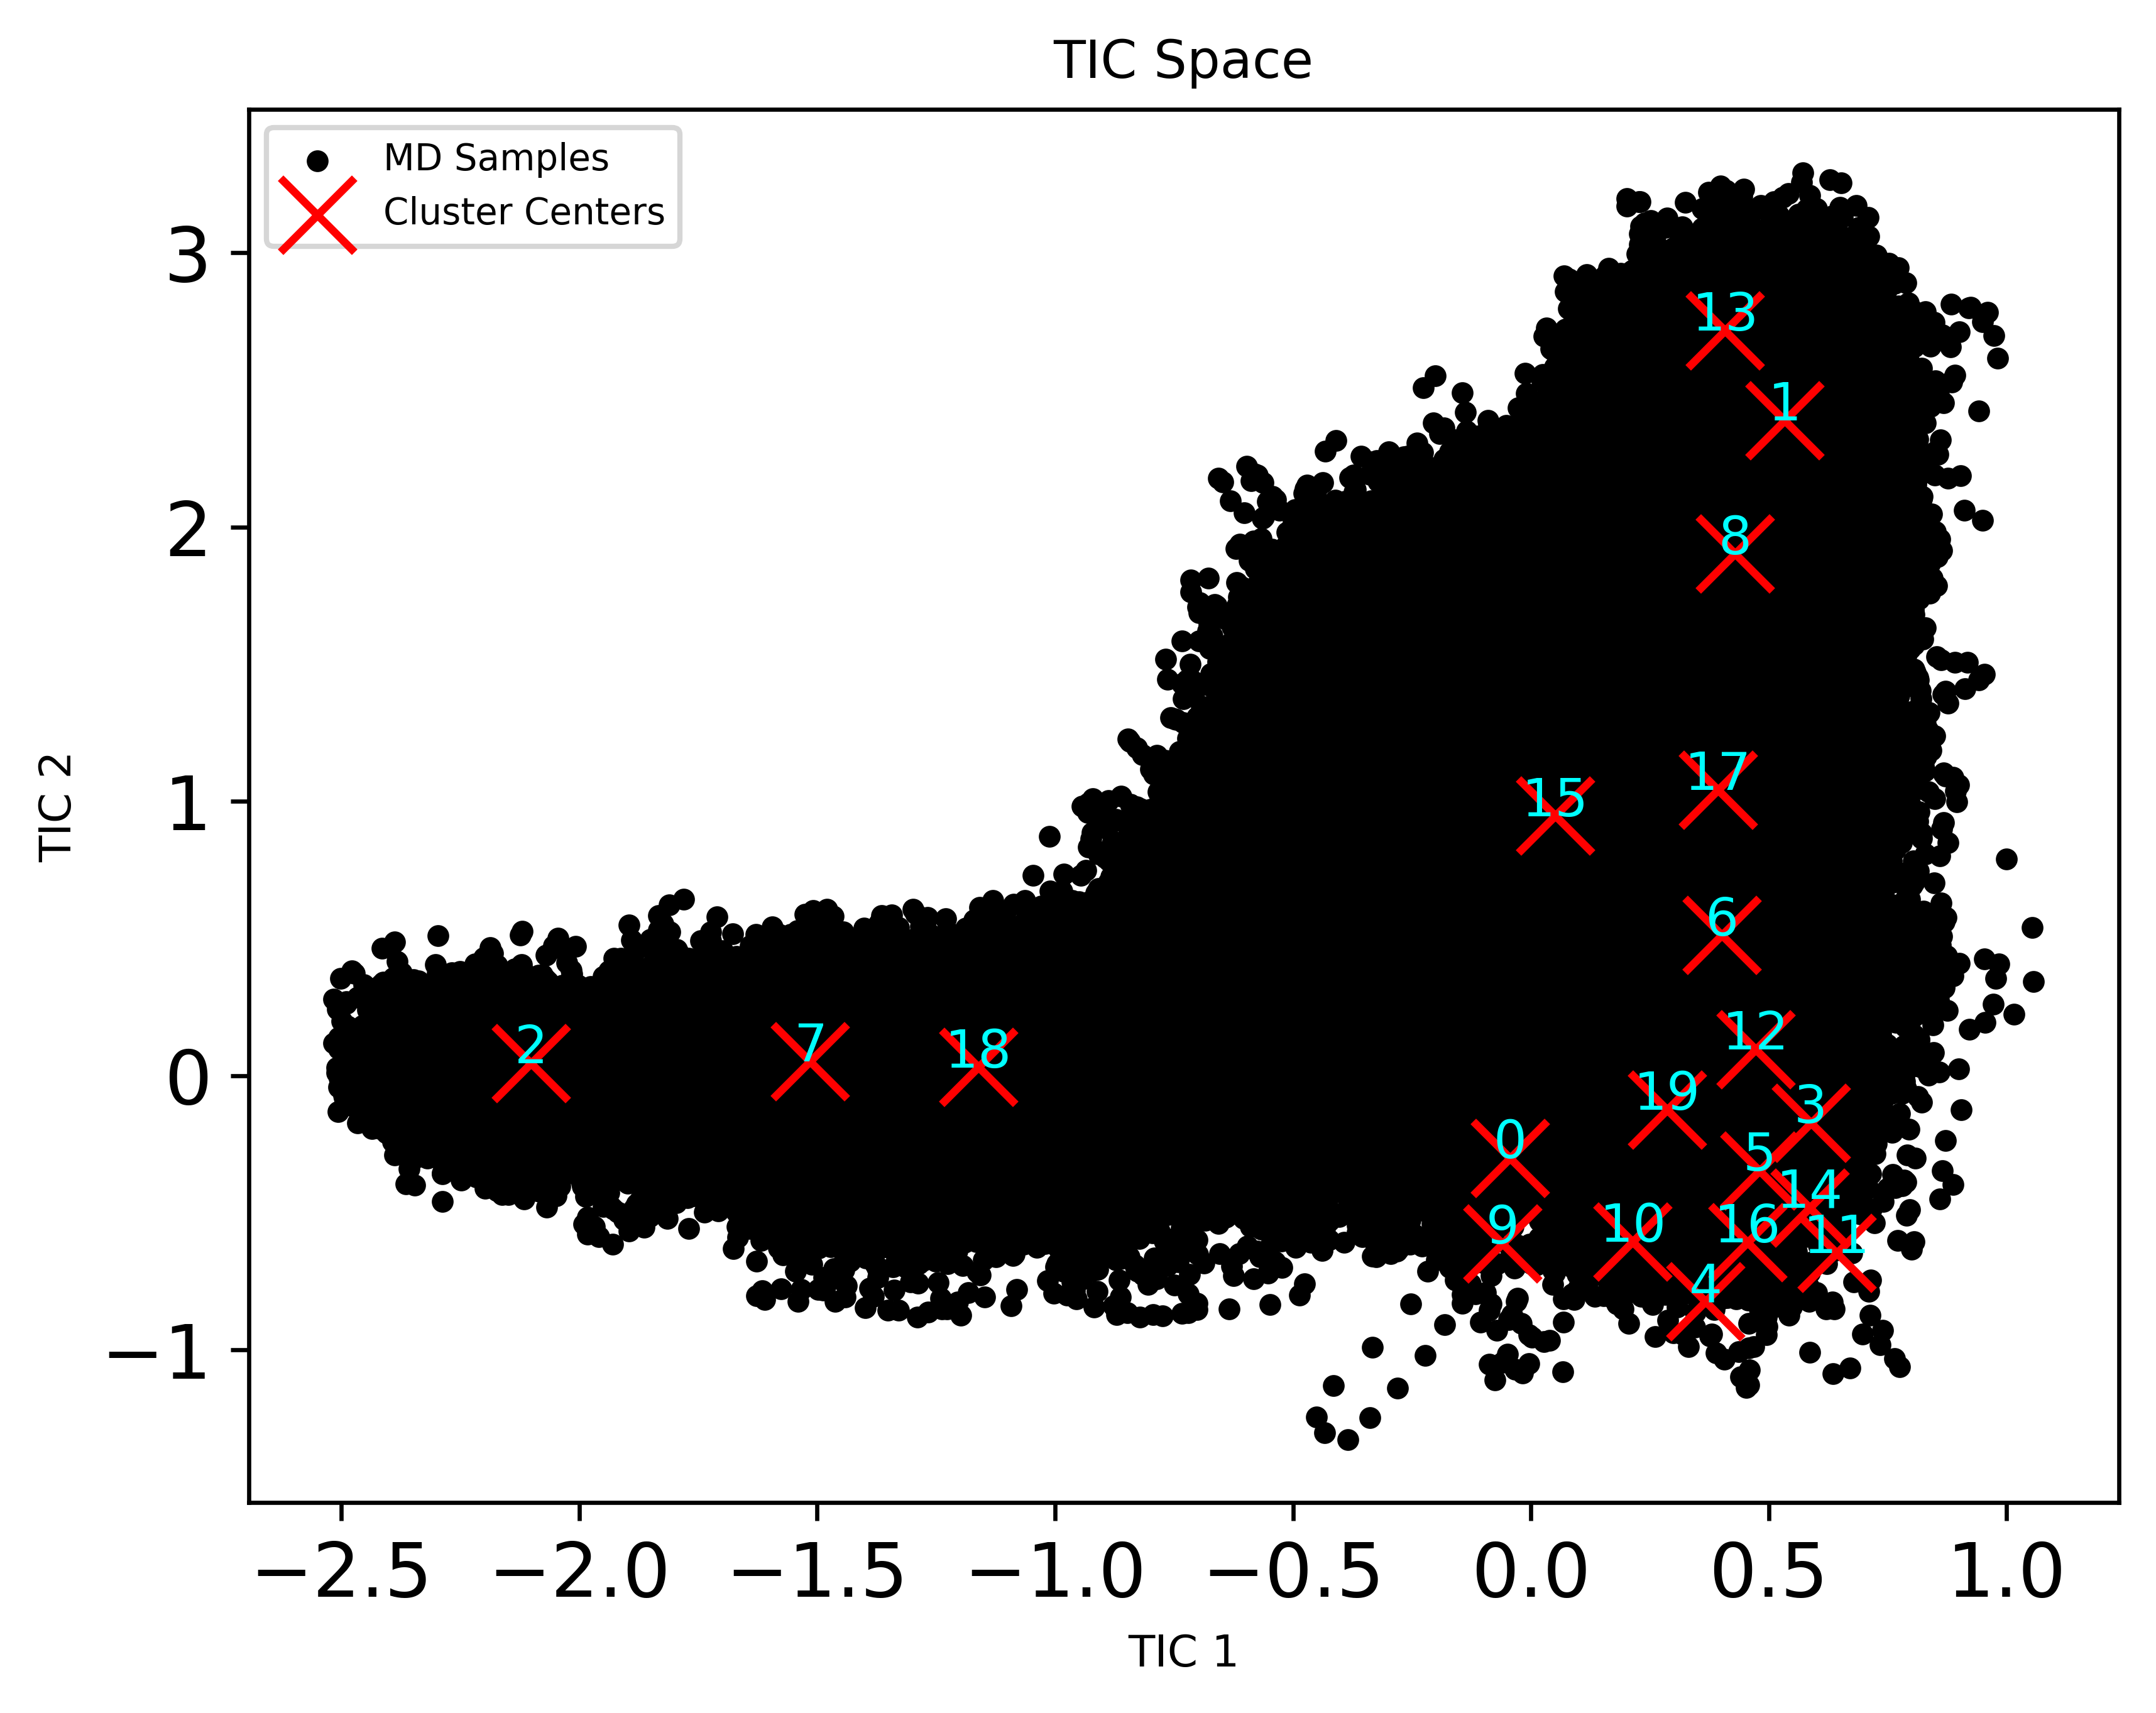

In [5]:
# Plot the TICA space with black points and red 'x' markers for cluster centers
plt.figure()
plt.scatter(transformed_samples[:, 0], transformed_samples[:, 1], c='black', s=10, label="MD Samples")
plt.scatter(tic_cluster_coords[:, 0], tic_cluster_coords[:, 1], c='red', s=200, marker='x', label='Cluster Centers')

# Add a text label above each cluster center with its index
for i, (x, y) in enumerate(tic_cluster_coords):
    plt.text(x, y, str(i), color='cyan', fontsize=10, ha='center')

# Set plot title and axis labels
plt.title("TIC Space")
plt.xlabel("TIC 1")
plt.ylabel("TIC 2")

# Show the plot
plt.legend()
plt.show()

In [5]:
# Digitize samples into bins
bins_x = np.digitize(transformed_samples[:, 0], tic_evaluator.bin_edges_x) - 1
bins_y = np.digitize(transformed_samples[:, 1], tic_evaluator.bin_edges_y) - 1

# Clip to ensure all indices are within bounds
bins_x = np.clip(bins_x, 0, tic_evaluator.bins - 1)
bins_y = np.clip(bins_y, 0, tic_evaluator.bins - 1)

reweighting_factors = torch.tensor(tic_evaluator.gt_prob[bins_x, bins_y]) + 1e-5

In [7]:
# # compute assignments of trajectories to clusters defined by OM path waypoints
# def nullspace(A, atol=1e-13, rtol=0):
#     #Helper function to obtain null space
#     A = np.atleast_2d(A)
#     u, s, vh = np.linalg.svd(A)
#     tol = max(atol, rtol * s[0])
#     nnz = (s >= tol).sum()
#     ns = vh[nnz:].conj().T
#     ss = s[nnz:]
#     return ns, ss

# def compute_reweighting_factors(Kmatrix, tol=2e-9):
#     """Adapted from https://github.com/muhammadhasyim/tps-torch
#     Computes the reweighting factor z_l for each node point by solving an eigenvalue problem
        
#     Args:
#         Kmatrix (torch.Tensor): [n_path_points, n_path_points] tensor of transition rates between path points during MD simulation.
#         tol (float): Tolerance value for the off-diagonal elements of the Kmatrix. Default is 2e-9.
#     See Appendix A of paper 
#     https://pubs.aip.org/aip/jcp/article/157/18/184111/2842057/Supervised-learning-and-the-finite-temperature for more details.
#     """
    
#     N = Kmatrix.shape[0]
# 	#Add tolerance values to the off-diagonal elements
#     for i in range(N):
#         for j in range(N):
#             if abs(i-j) == 1:
#                 Kmatrix[i, j] += tol
        
#     #Build the final matrix
#     Kmatrix = Kmatrix.t()-torch.diag(torch.sum(Kmatrix,dim=1)-tol)
#     #Compute the reweighting factors using an eigensolver
#     v, w = nullspace(Kmatrix.numpy(), atol=tol)
#     try:
#         index = np.argmin(w)
#         zl = np.real(v[:,index])
#     except:
#         print("Failed")
#         #Shift value may not be small enough so we choose a default higher tolerance detection
#         v, w = nullspace(Kmatrix.numpy(), atol=10**(-5), rtol=0)
#         index = np.argmin(w)
#         zl = np.real(v[:,index])
    
#     #Normalize
#     zl /= np.sum(zl)  
#     return zl


# #Assign OM clusters to each frame based on distances to the OM optimized paths

# md_samples = md_samples.to(device)
# om_points = om_points.to(device)
# import pdb; pdb.set_trace()
# # TODO: kabsch align the every frame to the first OM point
# distances = torch.linalg.norm(md_samples.unsqueeze(1) - om_points.unsqueeze(0), dim=(-2, -1))
# om_cluster_assignments = torch.argmin(distances, dim=1)

# # Compute transition counts between OM clusters
# n_clusters = len(om_points)
# transition_counts = torch.zeros((n_clusters, n_clusters)).to(device)
# print("Computing transition rates between OM path waypoints")
# om_cluster_assignments = om_cluster_assignments.reshape(-1, 1000)
# for traj in tqdm(range(om_cluster_assignments.shape[0])):
#     for i in range(1, om_cluster_assignments.shape[1]):
#         transition_counts[om_cluster_assignments[traj, i-1], om_cluster_assignments[traj, i]] += 1

# # Remove clusters that have no population

# # Compute reweighting factors based on the OM cluster assignments 


--Return--
None
> /tmp/ipykernel_977259/672498799.py(52)<module>()
     50 md_samples = md_samples.to(device)
     51 om_points = om_points.to(device)
---> 52 import pdb; pdb.set_trace()
     53 # kabsch align the every frame to the first OM point
     54 



torch.Size([1600, 20, 3])


In [6]:
def get_gt_committor_probs(tic_samples, start_cluster, end_cluster, clusters, tic):
    n_samples = tic_samples.shape[0]
    
    
    # Digitize samples into bins
    bins_x = np.digitize(tic_samples[:, 0], tic.bin_edges_x) - 1
    bins_y = np.digitize(tic_samples[:, 1], tic.bin_edges_y) - 1
    
    # Clip to ensure all indices are within bounds
    bins_x = np.clip(bins_x, 0, tic.bins - 1)
    bins_y = np.clip(bins_y, 0, tic.bins - 1)
    
    # Create bin index based on (x, y) bin pairs
    bin_idx = bins_x * tic.bins + bins_y
    
    # Initialize committor probabilities tensor
    committor_probs = torch.zeros(tic.bins ** 2)
    bin_counts = torch.zeros(tic.bins ** 2)
    
    # Boolean masks for start and end cluster transitions
    is_start = (clusters == start_cluster)
    is_end = (clusters == end_cluster)
    
    last_committor = None
    last_transition_idx = None

    # Iterate over samples to assign committor probabilities
    for i in tqdm(range(n_samples)):
        bin_counts[bin_idx[i]] += 1
        if last_transition_idx is not None and i <= last_transition_idx:
            # If we already determined the committor for the intermediate steps, assign and skip
            committor_probs[bin_idx[i]] += last_committor
        else:
            if is_start[i]:
                committor_probs[bin_idx[i]] += 0
                last_committor = 0
                last_transition_idx = i
            elif is_end[i]:
                committor_probs[bin_idx[i]] += 1
                last_committor = 1
                last_transition_idx = i
            else:
                # Search forward in the trajectory to find the next transition
                subsequent_clusters = clusters[i:]
                first_start = np.argmax(subsequent_clusters == start_cluster)
                first_end = np.argmax(subsequent_clusters == end_cluster)

                if (first_end == 0 or first_start > 0 and first_start < first_end):
                    last_committor = 0
                    last_transition_idx = i + first_start
                elif (first_end > 0 and (first_start == 0 or first_end < first_start)):
                    last_committor = 1
                    last_transition_idx = i + first_end
                else:
                    raise RuntimeError(f"No transition found for sample {i}")
                
                # Assign committor for current step
                committor_probs[bin_idx[i]] += last_committor
    
    # Normalize committor probabilities by bin counts
    committor_probs = committor_probs / torch.clamp(bin_counts, min=1)
    
    # Save bin-wise committor probabilities
    
    return committor_probs[bin_idx]


start, end = CLUSTER_ENDPOINTS[protein_name]
probs = get_gt_committor_probs(transformed_samples, start, end, tic_cluster_assignments, tic_evaluator)
probs = torch.tensor(probs)


100%|██████████| 160000/160000 [00:02<00:00, 59855.38it/s]
/tmp/ipykernel_1442022/482437351.py:70: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  probs = torch.tensor(probs)


In [7]:
# Ground truth rates (ns ^ -1) obtained from counting reference MD simulations
gt_rates = {
    "chignolin": 5.1e-4,
    "trp_cage": 1.89e-4,
    "bba": 4.91e-5,
    "villin": 5.97e-5,
    "ntl9": 9.47e-5,
}

def get_transition_rate(tic_samples, start_cluster, end_cluster, clusters, tic, lagtime_ns=0.2):
    # get the transition rate from start to end cluster using direct counting
    tic_samples = tic_samples.reshape(1600, -1, 2)
    clusters = clusters.reshape(1600, -1)
    n_traj, traj_len = tic_samples.shape[0], tic_samples.shape[1]
    
    # Digitize samples into bins
    bins_x = np.digitize(tic_samples[:, :, 0], tic.bin_edges_x) - 1
    bins_y = np.digitize(tic_samples[:, :, 1], tic.bin_edges_y) - 1
    
    # Clip to ensure all indices are within bounds
    bins_x = np.clip(bins_x, 0, tic.bins - 1)
    bins_y = np.clip(bins_y, 0, tic.bins - 1)
    
    # Create bin index based on (x, y) bin pairs
    bin_idx = bins_x * tic.bins + bins_y
    
    # Initialize committor probabilities tensor
    first_passage_times = []
    
    # Boolean masks for start and end cluster transitions
    is_start = (clusters == start_cluster)
    is_end = (clusters == end_cluster)
    
    last_committor = None
    last_transition_idx = None

    # Iterate over samples to assign committor probabilities
    for traj in tqdm(range(n_traj)):
        t=0
        count=0
        while t < traj_len:
            if is_start[traj, t]:  # Found a start state
                subsequent_clusters = clusters[traj, t:]  

                # Check if a transition exists
                if (subsequent_clusters == end_cluster).any():              
                    first_end = np.argmax(subsequent_clusters == end_cluster)  # Find first passage
                    # Create an array of indices in the range [i, i + first_end]
                    valid_start_indices = np.arange(t, t + first_end + 1)[is_start[traj, t:t + first_end + 1]]
                    # Compute passage times using vectorized operations
                    passage_times = lagtime_ns * (t + first_end - valid_start_indices)
                    # Efficiently extend the list in one operation
                    first_passage_times.extend(passage_times)
                    t += first_end  # Skip ahead to the next relevant point
                else:
                    break # No valid transition found, exit
            else:
                t += 1  # Skip non-start states
            count +=1
            
    
    first_passage_time = np.mean(np.array(first_passage_times))
    rate = 1 / first_passage_time
    
    return rate

# Direct Counting 
start, end = CLUSTER_ENDPOINTS[protein_name]
direct_counting_rate = get_transition_rate(transformed_samples, start, end, tic_cluster_assignments, tic_evaluator, lagtime_ns=4e-6)
print(f"Rate from direct counting: {direct_counting_rate} ns-1")

import numpy as np
import torch
from deeptime.markov.tools.analysis import mfpt
prob_mat = np.load(f"./evaluate/saved_references/saved_transition_matrix_{(protein_name).upper()}.npy")
fpt = mfpt(prob_mat, end, start, tau=0.2)
msm_rate = 1 / fpt
print(f"Rate from MSM analysis: {msm_rate} ns^-1")


  0%|          | 0/1600 [00:00<?, ?it/s]

100%|██████████| 1600/1600 [00:00<00:00, 4754.32it/s]

Rate from direct counting: nan ns-1
Rate from MSM analysis: 0.004010886571750428 ns^-1



/home/sanjeevr/miniforge3/envs/alphaflow/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3440: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/sanjeevr/miniforge3/envs/alphaflow/lib/python3.9/site-packages/numpy/core/_methods.py:189: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


Epoch 1


100%|██████████| 125/125 [00:07<00:00, 15.71it/s]


Epoch 2


100%|██████████| 125/125 [00:07<00:00, 16.22it/s]


Epoch 3


...

100%|██████████| 125/125 [00:07<00:00, 16.28it/s]


Epoch 99


100%|██████████| 125/125 [00:07<00:00, 16.18it/s]


Epoch 100


100%|██████████| 125/125 [00:07<00:00, 16.06it/s]


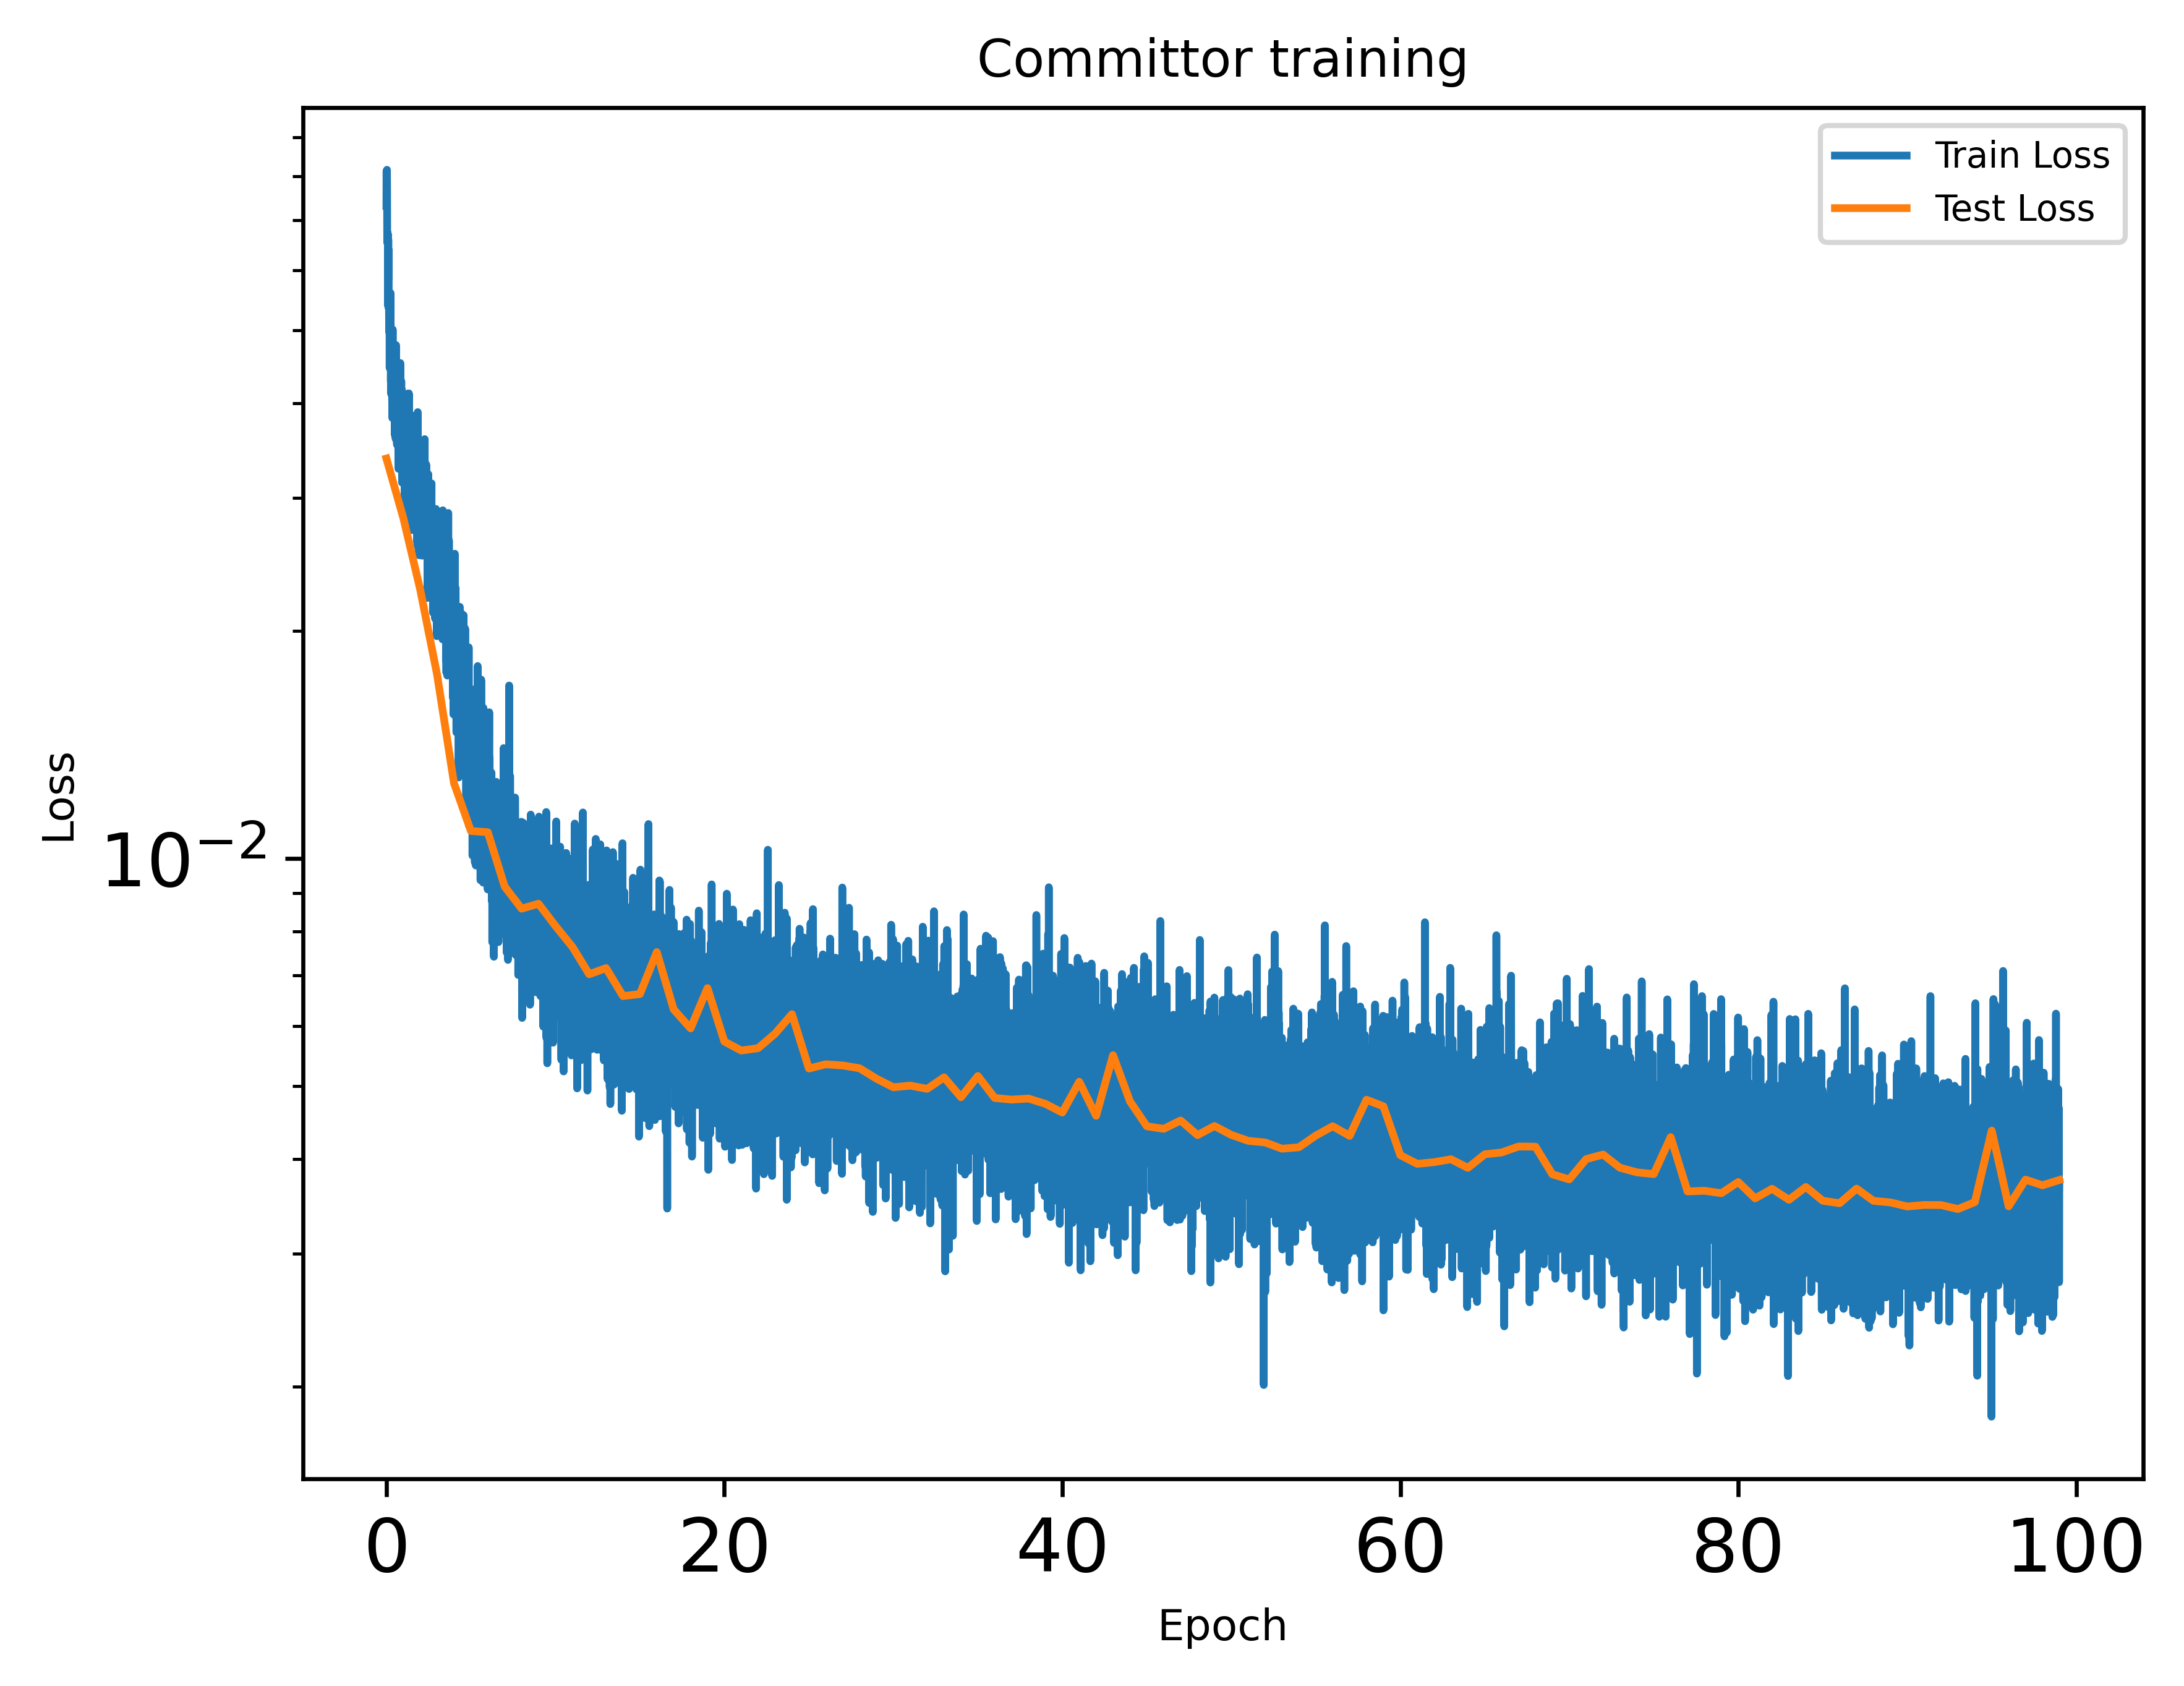

In [8]:
# Model training

model = GraphTransformer(num_beads = n_atoms, n_layers = 2, hidden_nf=64, conservative=True).to(device)

from models import CommittorNN
from utils import random_rotation


committor_model = CommittorNN(model)

# Train the model on the sampled molecules
batch_size = 1024
n_epochs = 100
max_data_size = 160000
data_augmentation = True
filter_transition = True
sl_loss_coeff = 1.0
grad_loss_coeff = 0.0
start_loss_coeff = 0.0
end_loss_coeff = 0.0
idxs = np.random.choice(md_samples.shape[0], max_data_size, replace=False)
optimizer = torch.optim.Adam(committor_model.parameters(), lr=1e-5, weight_decay=1e-4)
scheduler = linear_warmup_cosine_decay_lr_scheduler(optimizer, warmup_steps = 200, \
                                                        total_steps = n_epochs * int(0.8 * max_data_size / batch_size), \
                                                        lr_min=0.9, lr_max=1.0)
train_losses = []
test_losses = []

# split sampled_mol and cluster_assignments into train test sets
md_samples_keep = md_samples[idxs]
md_samples_keep = md_samples_keep - md_samples_keep.mean(1, keepdims=True)

tic_cluster_assignments_keep = tic_cluster_assignments[idxs]
reweighting_factors_keep = reweighting_factors[idxs]
probs_keep = probs[idxs]

x_train, x_test, tic_cluster_train, tic_cluster_test, weights_train, weights_test, probs_train, probs_test = train_test_split(md_samples_keep, tic_cluster_assignments_keep, reweighting_factors_keep, probs_keep, test_size=0.2)
trainset = torch.utils.data.TensorDataset(x_train, tic_cluster_train, weights_train, probs_train)
train_dataloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True)

testset = torch.utils.data.TensorDataset(x_test, tic_cluster_test, weights_test, probs_test)
test_dataloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False)

for e in range(n_epochs):
    committor_model.train()
    print(f"Epoch {e+1}")
    for x, tic_cluster, weights, prob in tqdm(train_dataloader):
        
        optimizer.zero_grad()
        x = x.to(device).requires_grad_(True)
        x = (x - x.mean(1, keepdim=True)) / norm_stds[Molecules[protein_name.upper()]]
        if data_augmentation:
            x = random_rotation(x)
        tic_cluster = tic_cluster.to(device)
        prob = prob.to(device)
        weights = weights.to(device)
        
        start_mask = tic_cluster == start
        end_mask = tic_cluster == end
        if filter_transition:
            transition_mask = torch.logical_and(~start_mask, ~end_mask)
        else:
            transition_mask = torch.ones_like(start_mask)
        h = torch.eye(n_atoms).to(device)
        t = torch.zeros((x.shape[0], )).to(device)
        pred_prob = committor_model(x, h, t)
        if grad_loss_coeff > 0:
            grad_prob = torch.autograd.grad(
                outputs=pred_prob,  # [batch_size, ]
                inputs=x,  # [batch_size, n_nodes, 3]
                grad_outputs=torch.ones_like(pred_prob),
                retain_graph=True,  # Make sure the graph is not destroyed during training
                create_graph=True,  # Create graph for second derivative
                allow_unused=True,
                )[0]
        else:
            grad_prob = torch.zeros_like(x)
        grad_loss = 0
        start_boundary_loss = 0
        end_boundary_loss = 0
        sl_loss = 0

        batch_weights = weights[transition_mask]
        batch_weights = batch_weights / batch_weights.sum()
        grad_loss = (batch_weights * grad_prob.square().sum((-2, -1))[transition_mask]).sum()
        if start_mask.sum() > 0:
            start_boundary_loss = (pred_prob**2)[start_mask].mean()
        if end_mask.sum() > 0:
            end_boundary_loss = ((1 - pred_prob)**2)[end_mask].mean()
        
        sl_loss = (pred_prob - prob).square().mean()
        loss = loss = sl_loss_coeff*sl_loss + start_loss_coeff*start_boundary_loss + end_loss_coeff*end_boundary_loss + grad_loss_coeff*grad_loss

        loss.backward()
        optimizer.step()
        scheduler.step()
        train_losses.append(loss.detach().unsqueeze(-1) if grad_loss_coeff == 0 else KB / (norm_stds[Molecules[protein_name.upper()]]**2) * temp_data / (friction * masses) *grad_loss.detach().unsqueeze(-1))
        

    # Test the model on the test set
    committor_model.eval()
    tls = []
    for x, tic_cluster, weights, prob in test_dataloader:
        x = x.to(device).requires_grad_(True)
        x = (x - x.mean(1, keepdim=True)) / norm_stds[Molecules[protein_name.upper()]]
        tic_cluster = tic_cluster.to(device)
        prob = prob.to(device)
        weights = weights.to(device)
        start_mask = tic_cluster == start
        end_mask = tic_cluster == end
        if filter_transition:
            
            transition_mask = torch.logical_and(~start_mask, ~end_mask)
        else:
            transition_mask = torch.ones_like(start_mask)
        h = torch.eye(n_atoms).to(device)
        t = torch.zeros((x.shape[0], )).to(device)
        pred_prob = committor_model(x, h, t)
        if grad_loss_coeff > 0:
            grad_prob = torch.autograd.grad(
                outputs=pred_prob,  # [batch_size, ]
                inputs=x,  # [batch_size, n_nodes, 3]
                grad_outputs=torch.ones_like(pred_prob),
                retain_graph=True,  # Make sure the graph is not destroyed during training
                create_graph=True,  # Create graph for second derivative
                allow_unused=True,
                )[0]
        else:
            grad_prob = torch.zeros_like(x)
        grad_loss = 0
        start_boundary_loss = 0
        end_boundary_loss = 0

        batch_weights = weights[transition_mask]
        batch_weights = batch_weights / batch_weights.sum()

        grad_loss = (batch_weights * grad_prob.square().sum((-2, -1))[transition_mask]).sum()
        if start_mask.sum() > 0:
            start_boundary_loss = (pred_prob**2)[start_mask].mean()
        if end_mask.sum() > 0:
            end_boundary_loss = ((1 - pred_prob)**2)[end_mask].mean()

        sl_loss = (pred_prob - prob).square().mean()

        loss = loss = sl_loss_coeff*sl_loss + start_loss_coeff*start_boundary_loss + end_loss_coeff*end_boundary_loss + grad_loss_coeff*grad_loss
        tls.append(loss.detach().unsqueeze(-1) if grad_loss_coeff == 0 else KB / (norm_stds[Molecules[protein_name.upper()]]**2) * temp_data / (friction * masses) *grad_loss.detach().unsqueeze(-1))
    
    test_loss = torch.cat(tls).sum(0) / len(tls)
    test_losses.append(test_loss.unsqueeze(-1))


train_losses = torch.cat(train_losses).cpu().numpy()
test_losses = torch.cat(test_losses).cpu().numpy()

plot_losses(train_losses, test_losses, "Committor training", true_rate=gt_rates[protein_name] if grad_loss_coeff > 0 else None)

# Save the model
torch.save(committor_model, f"./saved_models/{protein_name}/committor-rate-model-{start}_{end}.pt")


100%|██████████| 32/32 [00:00<00:00, 44.22it/s]


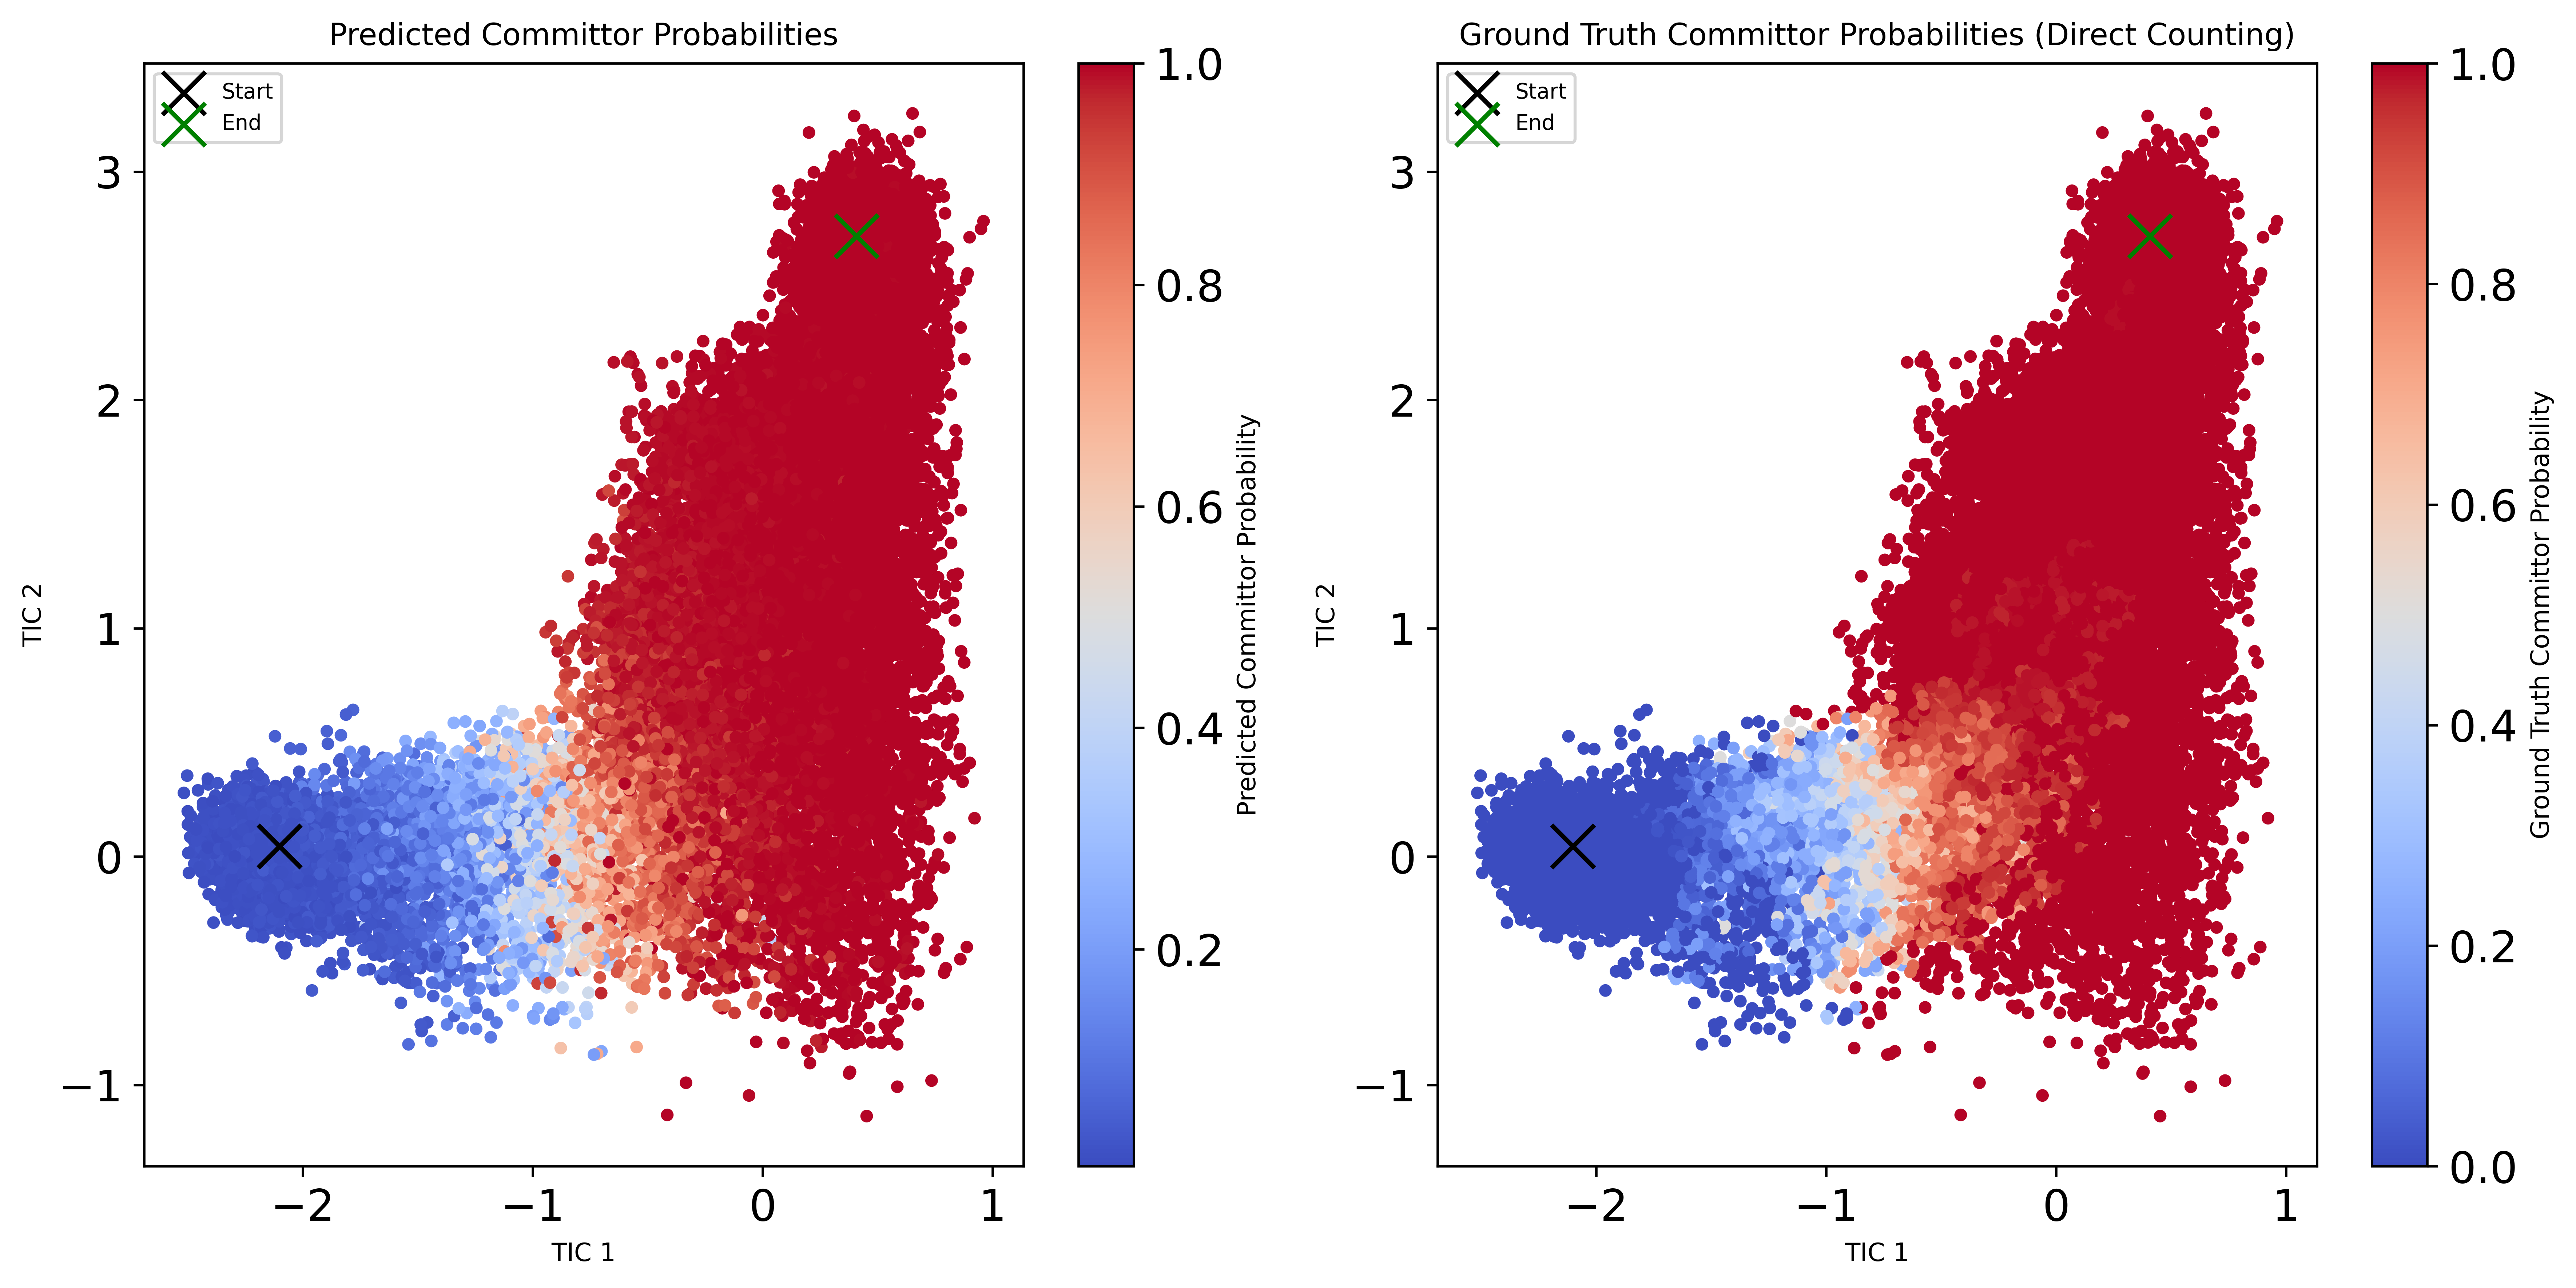

In [9]:
# Import necessary libraries
import matplotlib.pyplot as plt
import torch
from tqdm import tqdm

# Evaluate the committor model and get predicted probabilities
committor_model.eval()

committor_probs = []
for x in tqdm(x_test.split(batch_size)):
    x = x.to(device).requires_grad_(True)
    x = (x - x.mean(1, keepdim=True)) / norm_stds[Molecules[protein_name.upper()]]
    h = torch.eye(n_atoms).to(device)
    t = torch.zeros((x.shape[0], )).to(device)
    pred_prob = committor_model(x, h, t)
    committor_probs.append(pred_prob.detach())

committor_probs = torch.cat(committor_probs).cpu().detach().numpy()

# Get TICA for the ground truth data
sample_tic_features = tic_evaluator.get_tic_features(
        x_test, tic_evaluator.folded
    )
transformed_samples = tic_evaluator.tica(sample_tic_features)

# Create a side-by-side plot
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Plot the predicted committor probabilities
scatter1 = axs[0].scatter(transformed_samples[:, 0], transformed_samples[:, 1], c=committor_probs, cmap='coolwarm', s=10)
axs[0].set_title('Predicted Committor Probabilities')
axs[0].set_xlabel('TIC 1')
axs[0].set_ylabel('TIC 2')
axs[0].scatter(tic_cluster_coords[start, 0], tic_cluster_coords[start, 1], c='black', s=200, marker='x', label='Start')
axs[0].scatter(tic_cluster_coords[end, 0], tic_cluster_coords[end, 1], c='green', s=200, marker='x', label='End')
axs[0].legend()
plt.colorbar(scatter1, ax=axs[0], label='Predicted Committor Probability')

# Plot the ground truth committor probabilities
scatter2 = axs[1].scatter(transformed_samples[:, 0], transformed_samples[:, 1], c=probs_test, cmap='coolwarm', s=10)
axs[1].set_title('Ground Truth Committor Probabilities (Direct Counting)')
axs[1].set_xlabel('TIC 1')
axs[1].set_ylabel('TIC 2')
axs[1].scatter(tic_cluster_coords[start, 0], tic_cluster_coords[start, 1], c='black', s=200, marker='x', label='Start')
axs[1].scatter(tic_cluster_coords[end, 0], tic_cluster_coords[end, 1], c='green', s=200, marker='x', label='End')
axs[1].legend()
plt.colorbar(scatter2, ax=axs[1], label='Ground Truth Committor Probability')

# Adjust layout and display the plot
plt.tight_layout()
plt.show()


In [10]:
from ase import units
def compute_rates(samples, weights, committor_model):
    """
    samples: torch.tensor of shape [N_samples, 2]
    weights: torch.tensor of shape [N_samples, 1]
    committor_model: NN trained to predict committor probabilities
    """
    weights = weights / weights.sum()
    # Loop over samples and compute grad of model-predicted committors
    committor_model.eval()
    committor_probs = []
    grad_committor_prob_norms = []
    for x in tqdm(samples.split(batch_size)):
        x = x.to(device).requires_grad_(True)
        x = (x - x.mean(1, keepdim=True)) / norm_stds[Molecules[protein_name.upper()]]
        x = x.to(torch.float32)
        h = torch.eye(n_atoms).to(device)
        t = torch.zeros((x.shape[0], )).to(device)
        pred_prob = committor_model(x, h, t)
        grad_prob = torch.autograd.grad(
            outputs=pred_prob,  # [batch_size]
            inputs=x,  # [batch_size, N_nodes, 3]
            grad_outputs=torch.ones_like(pred_prob),
            retain_graph=False,  # Make sure the graph is not destroyed during training
            create_graph=False,  # Create graph for second derivative
            allow_unused=True,
            )[0].detach()
        grad_committor_prob_norms.append(grad_prob.reshape(x.shape[0], -1).norm(dim=-1)**2)
    
    grad_committor_prob_norms = torch.cat(grad_committor_prob_norms)
    
    # Compute a weighted average of the grad of the committor (this is the rate)
    ensemble_average = (weights * grad_committor_prob_norms).sum()
    rate_ps = KB / (norm_stds[Molecules[protein_name.upper()]]**2) * temp_data / (friction * masses) * ensemble_average
    rate_ns = rate_ps * 1e3
    N_eff = (-weights * torch.log(weights)).sum().exp()  # effective sample size

    print(f"Rate (ns^-1): {rate_ns.item()}, Effective sample size: {N_eff} out of {len(samples)} samples")
    return rate_ns, N_eff

rate, N_eff = compute_rates(torch.tensor(md_samples_keep), torch.tensor(reweighting_factors_keep).to(device), committor_model)


/tmp/ipykernel_1442022/4181399168.py:41: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  rate, N_eff = compute_rates(torch.tensor(md_samples_keep), torch.tensor(reweighting_factors_keep).to(device), committor_model)
100%|██████████| 157/157 [00:07<00:00, 20.13it/s]

Rate (ns^-1): 20.949402312209678, Effective sample size: 42133.07080620036 out of 160000 samples


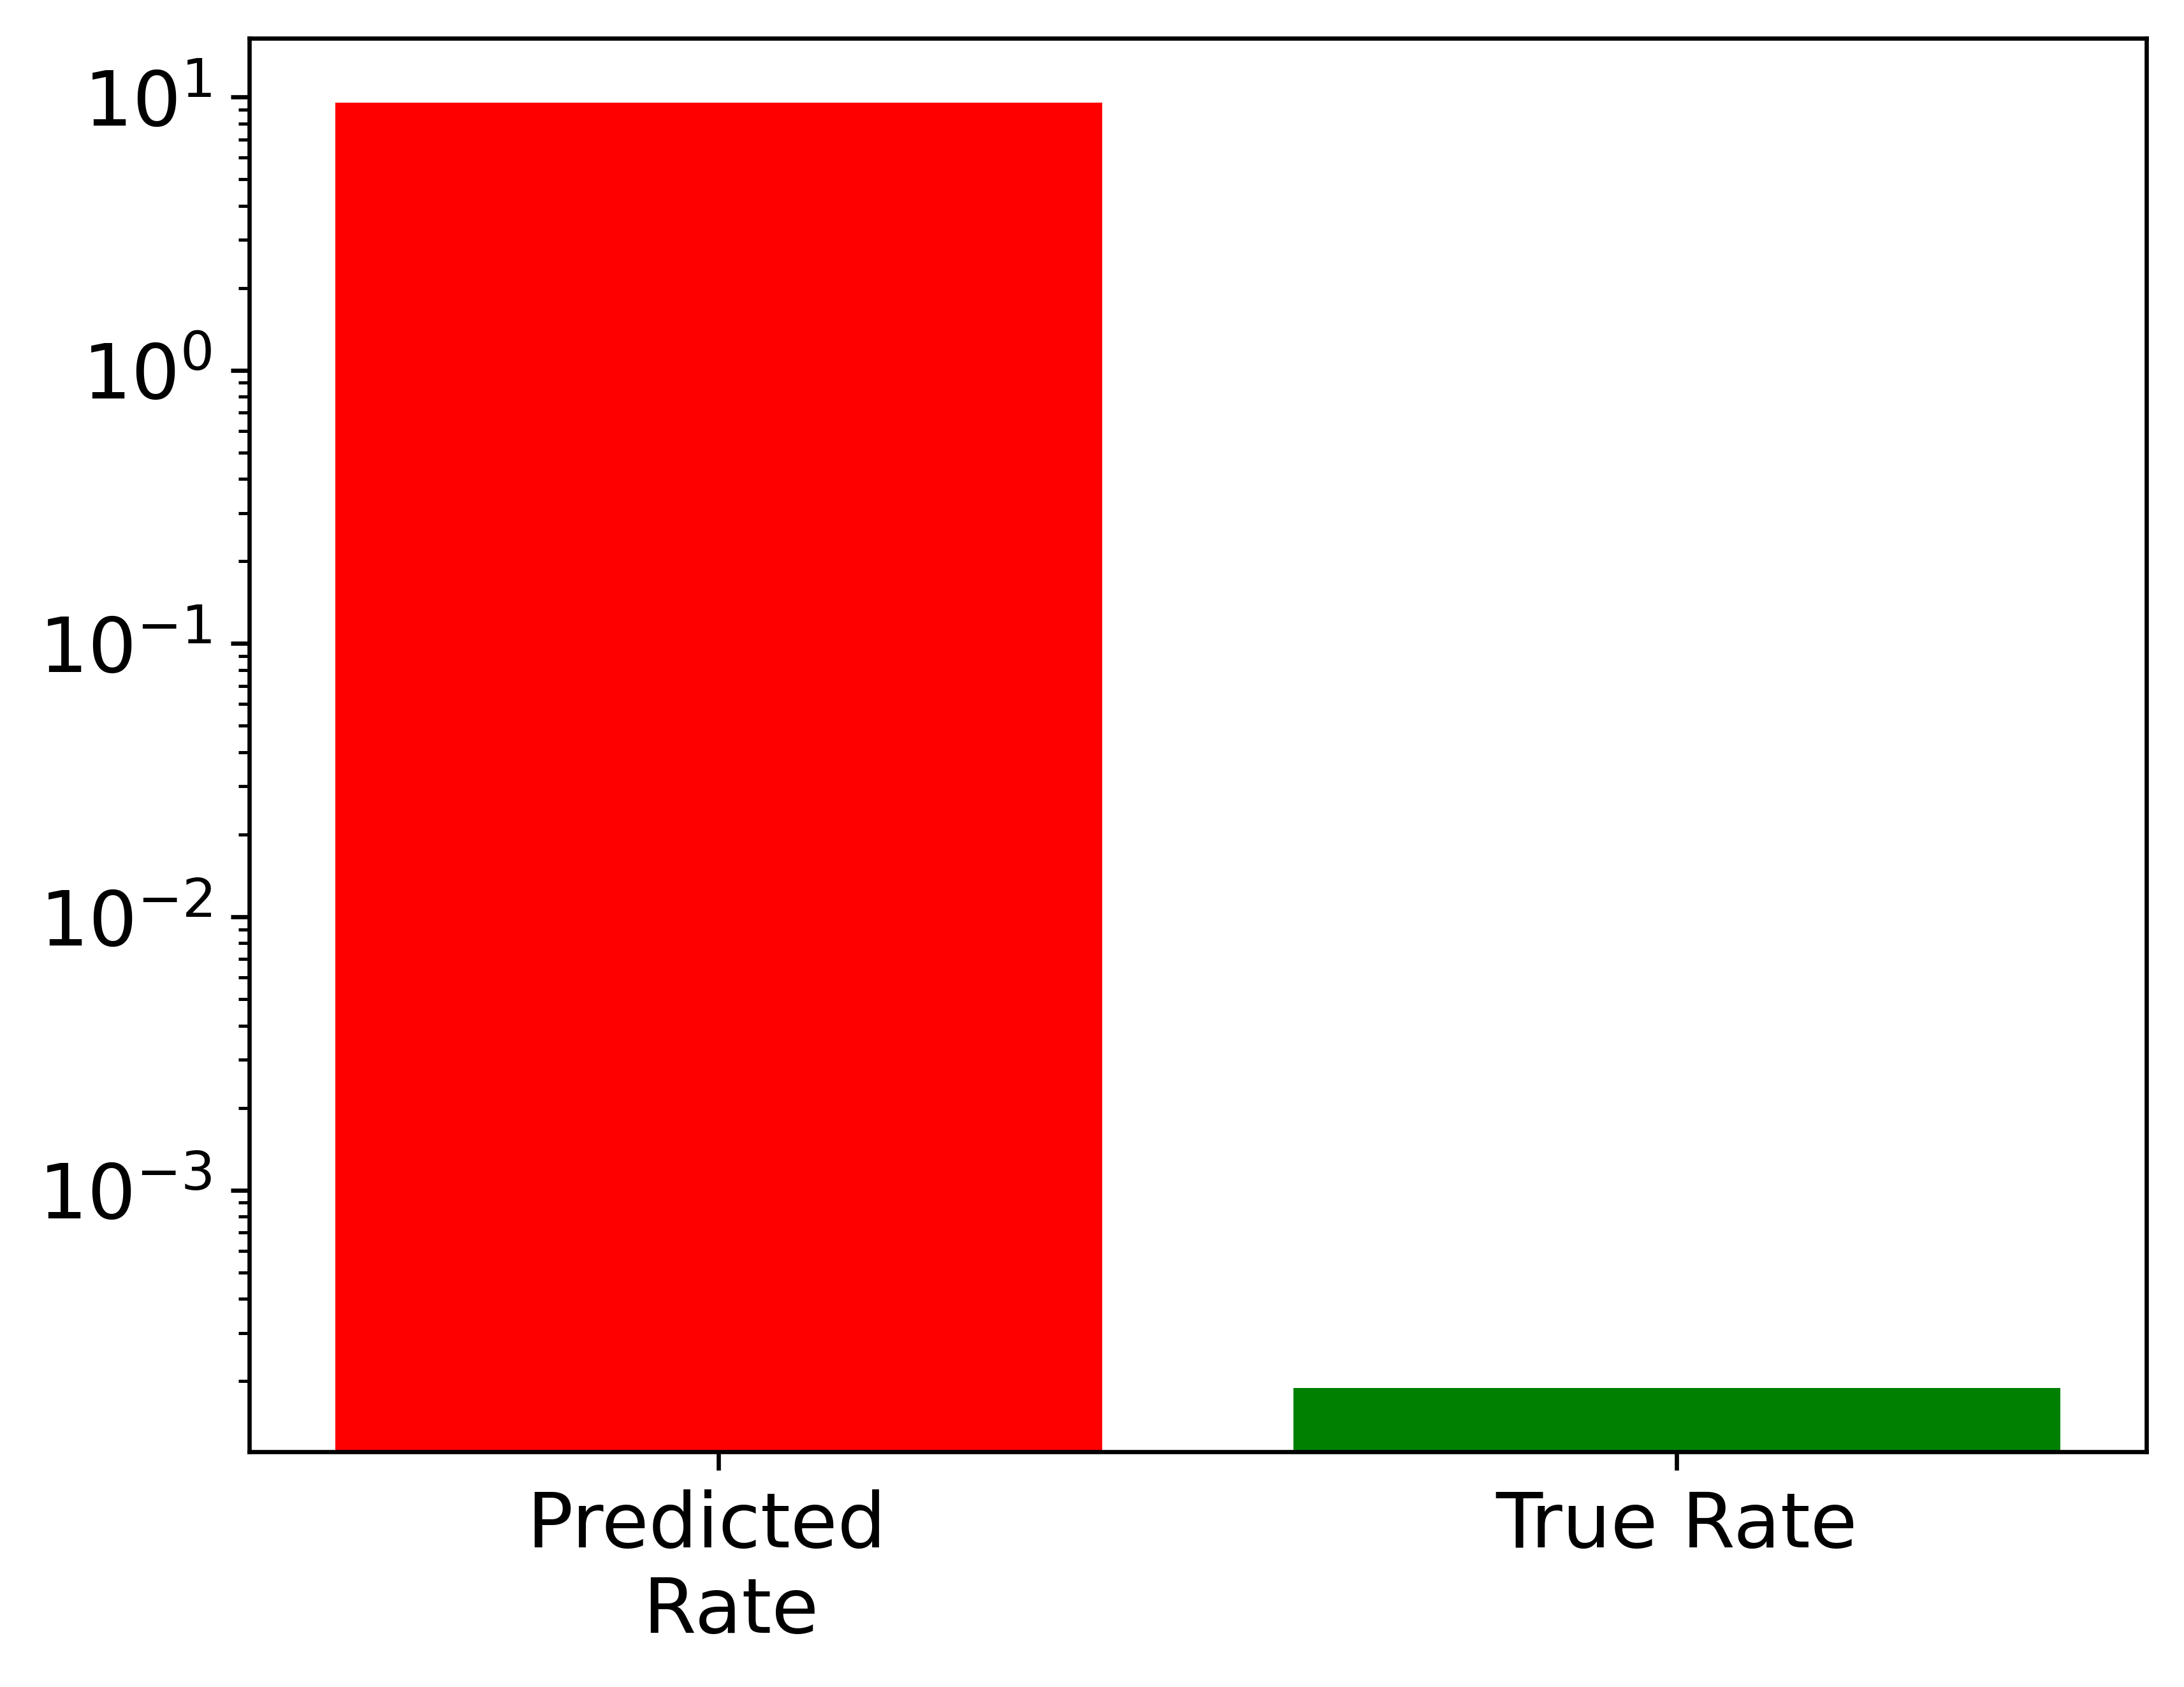

In [43]:

# bar plot of rate vs true rate
# plt.figure()
# plt.bar(["Predicted \n Rate", "True Rate"], [rate.item(), gt_rates[protein_name]], color=['red', 'green'])
# plt.yscale('log')
KB / (norm_stds[Molecules[protein_name.upper()]]**2) * temp_data / (friction * masses) * 1e3



tensor(-3.0761, dtype=torch.float64)